# Phishing Detection Model Comparison

Comparing the performance of:
1. Legacy Logistic Regression model with Pipeline
2. OpenAI GPT-4 based model

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import os
from openai import OpenAI
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import dotenv

# Load environment variables
dotenv.load_dotenv()

True

In [6]:
## 1. Load the Test Dataset
data = pd.read_csv('test_dataset.csv')

# Basic preprocessing
data = data.dropna()
data = data.drop_duplicates()
data = data.reset_index(drop=True)

# Create combined text field
data['text_combined_legacy'] = data['subject'] + " " + data['body']
data['text_combined_openai'] = "SENDER: " + data['sender'] + " SUBJECT: " + data['subject'] + "BODY: " + data['body']

# Display sample
print("Test dataset shape:", data.shape)
data.head()

Test dataset shape: (8503, 7)


,sender,subject,body,label,source,text_combined_legacy,text_combined_openai
0,ohwwlejs-pbfotbp@list.scms.waikato.ac.nz,"Wekalist Digest, Vol 60, Issue 11",Send Wekalist mailing list submissions to \tiu...,0,CEAS_08,"Wekalist Digest, Vol 60, Issue 11 Send Wekalis...",SENDER: ohwwlejs-pbfotbp@list.scms.waikato.ac....
1,under@hmo.megared.net.mx,A small thing to make your woman happy.,In Canadian Chemist we trust. http://urx.medic...,1,CEAS_08,A small thing to make your woman happy. In Can...,SENDER: under@hmo.megared.net.mx SUBJECT: A sm...
2,Isabelle Bichindaritz <kaupuiws@u.washington.edu>,[UAI] CFP CBR in the Health Sciences Workshop ...,\n\n Workshop on CBR in the H...,0,CEAS_08,[UAI] CFP CBR in the Health Sciences Workshop ...,SENDER: Isabelle Bichindaritz <kaupuiws@u.wash...
3,"""Elsy Moriarty"" <pekerhead@postino.ch>",Refinance or MortgageFKZQELJHYNO,<= FONT color=3D#66ccff size=3D5>What a Loan F...,1,SpamAssasin,Refinance or MortgageFKZQELJHYNO <= FONT color...,"SENDER: ""Elsy Moriarty"" <pekerhead@postino.ch>..."
4,Alissa Gallagher <ahynrqk@boegerwinery.com>,123,I got good news for you! That is a superb perf...,1,CEAS_08,123 I got good news for you! That is a superb ...,SENDER: Alissa Gallagher <ahynrqk@boegerwinery...


In [7]:
## 2. Load Legacy Model
# Load the saved pipeline that includes preprocessing, vectorization, and model
with open('email_classifier_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

In [13]:
## 3. OpenAI Model Setup
# Initialize OpenAI client
client = OpenAI(
    api_key=os.getenv('OPENAI_API_KEY'),
    organization=os.getenv('OPENAI_ORG_ID')
)

def predict_with_openai(text, max_retries=3):
    """Simplified version of the production predict_with_openai function"""
    system_prompt = """You are a cybersecurity expert specializing in phishing email detection. 
    Analyze the provided email and determine if it's a phishing attempt. 
    Consider sender domain legitimacy, urgency tactics, suspicious links, Consider urgency tactics, suspicious links, grammatical errors, too-good-to-be-true offers, and other markers. 
    You must respond with ONLY the word 'yes' if it's phishing or 'no' if it's legitimate.
    Do not include any other text, explanation, or punctuation in your response."""
    
    attempts = 0
    while attempts < max_retries:
        try:
            # Add small delay between requests
            time.sleep(1)
            
            response = client.chat.completions.create(
                model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                temperature=0.3,
                max_tokens=10
            )
            
            prediction = response.choices[0].message.content.strip().lower()
            
            if prediction in ["yes", "no"]:
                return prediction == "yes"
            
            attempts += 1
            
        except Exception as e:
            print(f"Error: {str(e)}")
            attempts += 1
            time.sleep(2)
    
    raise Exception(f"Failed to get valid response after {max_retries} attempts")

def predict_with_openai_v2(text, max_retries=3):
    """Simplified version of the production predict_with_openai function, using a new prompt"""
    system_prompt = """Determine if the email content suggests a potential phishing threat with a simple "yes" or "no" response.

    # Steps

    1. **Identify Red Flags**: 
    - Look for suspicious language, such as urgent requests for personal information, unverifiable sender details, or unexpected attachments.
    - Check for poor grammar, spelling mistakes, or awkward phrasing.

    2. **Evaluate Context**: 
    - Consider if the email requests sensitive information or actions that are unusual, like changing login credentials.
    - Assess the legitimacy of provided links or email addresses by looking for slight misspellings of trusted domains.

    3. **Analyze Tone and Format**: 
    - Note if the email uses aggressive or alarming language intended to prompt immediate action.
    - Evaluate the overall tone to see if it mimics trusted entities or uses titles improperly.

    # Output Format

    - Provide a single word response: "yes" if the email seems like a phishing attempt, otherwise "no".

    # Examples

    **Example 1:**

    - **Input**: "Congrats! You've won a prize! Click www.fakeurl123.com to claim now!"
    - **Reasoning**: The email promises a prize with a suspicious URL and urgency to click a link.
    - **Output**: "yes"

    **Example 2:**

    - **Input**: "Hello, can we reschedule our meeting to next week?"
    - **Reasoning**: The email content is a simple request with no suspicious elements.
    - **Output**: "no"

    # Notes

    - Be cautious of emails mimicking reputable organizations but having minor errors in logo, email address, or message structure.
    - Contextual understanding and evaluating subtle cues play a key role in distinguishing phishing attempts from legitimate emails."""
    
    attempts = 0
    while attempts < max_retries:
        try:
            # Add small delay between requests
            time.sleep(1)
            
            response = client.chat.completions.create(
                model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                temperature=0.3,
                max_tokens=10
            )
            
            prediction = response.choices[0].message.content.strip().lower()
            
            if prediction in ["yes", "no"]:
                return prediction == "yes"
            
            attempts += 1
            
        except Exception as e:
            print(f"Error: {str(e)}")
            attempts += 1
            time.sleep(2)
    
    raise Exception(f"Failed to get valid response after {max_retries} attempts")

In [14]:
## 4. Evaluation Functions
def evaluate_legacy_model(texts):
    """Evaluate the pipeline model"""
    return pipeline.predict(texts)

def evaluate_openai_model(texts, sample_size=100):
    """Evaluate the OpenAI model on a sample of texts"""
    # Sample texts to avoid excessive API calls
    if len(texts) > sample_size:
        sampled_indices = np.random.choice(len(texts), sample_size, replace=False)
        texts = texts[sampled_indices]
    
    predictions = []
    for text in tqdm(texts, desc="Processing with OpenAI"):
        try:
            pred = predict_with_openai(text)
            predictions.append(pred)
        except Exception as e:
            print(f"Error processing text: {str(e)}")
            predictions.append(None)
    
    return predictions

def evaluate_openai_model_v2(texts, sample_size=100):
    """Evaluate the OpenAI model on a sample of texts"""
    # Sample texts to avoid excessive API calls
    if len(texts) > sample_size:
        sampled_indices = np.random.choice(len(texts), sample_size, replace=False)
        texts = texts[sampled_indices]
    
    predictions = []
    for text in tqdm(texts, desc="Processing with OpenAI"):
        try:
            pred = predict_with_openai_v2(text)
            predictions.append(pred)
        except Exception as e:
            print(f"Error processing text: {str(e)}")
            predictions.append(None)
    
    return predictions


Legacy Model Performance:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4279
           1       0.99      0.99      0.99      4224

    accuracy                           0.99      8503
   macro avg       0.99      0.99      0.99      8503
weighted avg       0.99      0.99      0.99      8503



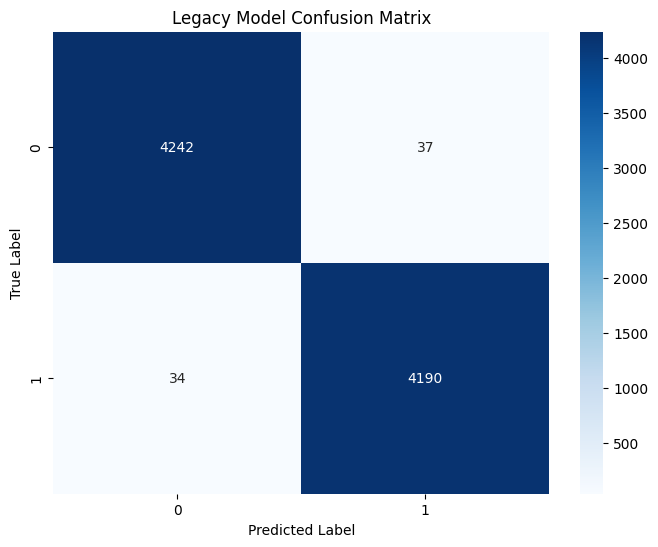

In [10]:
## 5. Model Comparison
# Evaluate legacy model on full test dataset
legacy_predictions = evaluate_legacy_model(data['text_combined_legacy'])
print("\nLegacy Model Performance:")
print(classification_report(data['label'], legacy_predictions))

# Create confusion matrix for legacy model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(data['label'], legacy_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Legacy Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Processing with OpenAI:  44%|████▍     | 3745/8503 [1:29:29<1:45:35,  1.33s/it]

Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150329 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150329 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150329 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}


Processing with OpenAI:  44%|████▍     | 3746/8503 [1:29:39<5:13:07,  3.95s/it]

Error processing text: Failed to get valid response after 3 attempts


Processing with OpenAI: 100%|██████████| 8503/8503 [3:22:07<00:00,  1.43s/it]  


OpenAI Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      4279
           1       0.88      0.97      0.93      4223

    accuracy                           0.92      8502
   macro avg       0.93      0.92      0.92      8502
weighted avg       0.93      0.92      0.92      8502



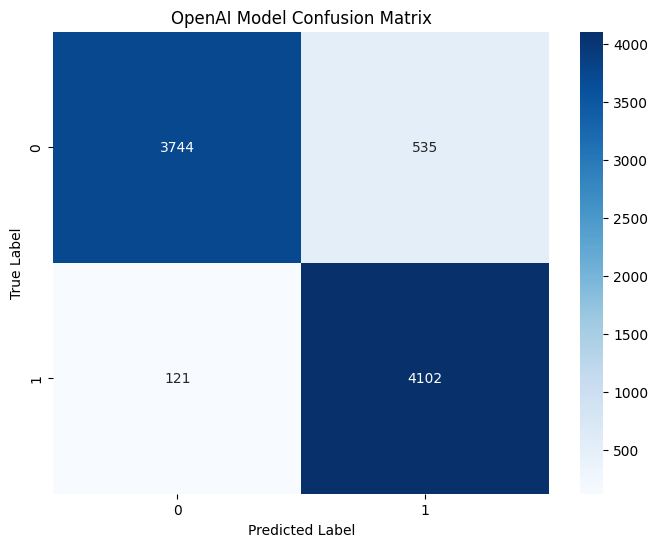

In [ ]:
# Evaluate OpenAI model on sample of test dataset
sample_size = len(data)  # Adjust based on API limits and budget
sampled_indices = np.random.choice(len(data), sample_size, replace=False)
sampled_data = data.iloc[sampled_indices]

openai_predictions = evaluate_openai_model(sampled_data['text_combined_openai'], sample_size=sample_size)

# Remove any None values from failed predictions
valid_indices = [i for i, pred in enumerate(openai_predictions) if pred is not None]
openai_predictions = [openai_predictions[i] for i in valid_indices]
openai_true_labels = sampled_data['label'].iloc[valid_indices]

print("\nOpenAI_v1 Model Performance:")
print(classification_report(openai_true_labels, openai_predictions))

# Create confusion matrix for OpenAI model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(openai_true_labels, openai_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('OpenAI Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Processing with OpenAI:  96%|█████████▌| 8166/8503 [3:12:54<07:39,  1.36s/it]  

Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150605 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150605 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150605 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}


Processing with OpenAI:  96%|█████████▌| 8167/8503 [3:13:05<22:59,  4.11s/it]

Error processing text: Failed to get valid response after 3 attempts


Processing with OpenAI: 100%|██████████| 8503/8503 [3:21:11<00:00,  1.42s/it]


OpenAI Model Performance:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      4279
           1       0.98      0.84      0.91      4223

    accuracy                           0.91      8502
   macro avg       0.92      0.91      0.91      8502
weighted avg       0.92      0.91      0.91      8502



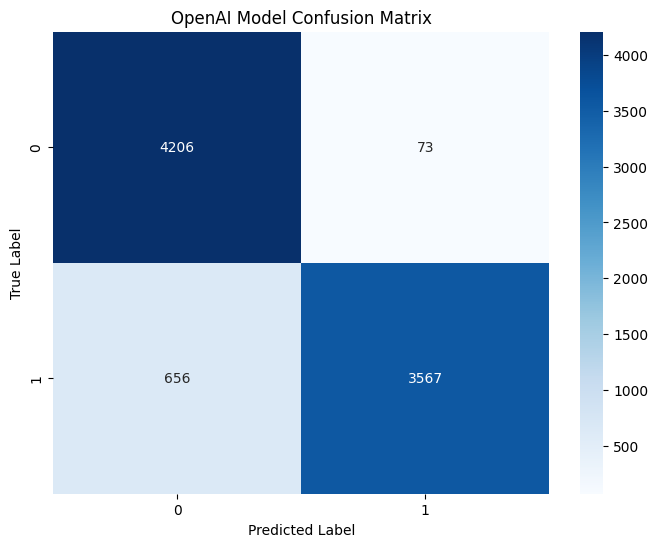

In [15]:
# Evaluate OpenAI model with new prompt on sample of test dataset
sample_size = len(data)  # Adjust based on API limits and budget
sampled_indices = np.random.choice(len(data), sample_size, replace=False)
sampled_data = data.iloc[sampled_indices]

openai_predictions = evaluate_openai_model_v2(sampled_data['text_combined_openai'], sample_size=sample_size)

# Remove any None values from failed predictions
valid_indices = [i for i, pred in enumerate(openai_predictions) if pred is not None]
openai_predictions = [openai_predictions[i] for i in valid_indices]
openai_true_labels = sampled_data['label'].iloc[valid_indices]

print("\nOpenAI_v2 Model Performance:")
print(classification_report(openai_true_labels, openai_predictions))

# Create confusion matrix for OpenAI model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(openai_true_labels, openai_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('OpenAI Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
## 6. Error Analysis
def analyze_errors(texts, true_labels, predictions, model_name):
    """Analyze misclassified examples"""
    errors = []
    for text, true_label, pred in zip(texts, true_labels, predictions):
        if true_label != pred:
            errors.append({
                'text': text,
                'true_label': true_label,
                'predicted': pred
            })
    
    print(f"\n{model_name} Error Analysis")
    print(f"Total errors: {len(errors)}")
    print(f"Error rate: {len(errors)/len(true_labels):.2%}")
    
    # Display a few example errors
    print("\nExample misclassifications:")
    for i, error in enumerate(errors[:3]):
        print(f"\nError {i+1}:")
        print(f"True label: {'Phishing' if error['true_label'] else 'Legitimate'}")
        print(f"Predicted: {'Phishing' if error['predicted'] else 'Legitimate'}")
        print(f"Text snippet: {error['text'][:200]}...")

# Analyze errors for both models
print("Legacy Model Errors:")
analyze_errors(data['text_combined_legacy'], data['label'], legacy_predictions, "Legacy Model")

print("\nOpenAI Model Errors:")
analyze_errors(
    sampled_data['text_combined_openai'].iloc[valid_indices],
    openai_true_labels,
    openai_predictions,
    "OpenAI Model"
)